# Kore2 Motorcycle Battery Performance Analysis
### Investigating Customer Reports of Rapid Drain & Abrupt Shutdowns

**Fleet:** 12 Kore2 batteries (KOFA battery-swap network, Nairobi pilot) &nbsp;·&nbsp; **Data:** `Kore2_battery_performance.csv` — 720 readings/battery at 30-second intervals over a ~6-hour window (08:00–14:00), 8,640 rows total &nbsp;·&nbsp; **Framework:** CRISP-DM (this notebook covers Data Understanding → Modeling → Evaluation; it is the technical artefact behind the accompanying industry brief and the deployed Fleet Ops dashboard)

---

## Contents
1. [Business Context & Stakeholders](#1.-Business-Context-&-Stakeholders)
2. [Executive Summary](#2.-Executive-Summary)
3. [Methodology](#3.-Methodology)
4. [Exploratory Data Analysis](#4.-Exploratory-Data-Analysis)
5. [Feature Engineering: Per-Battery Behavioural Summary](#5.-Feature-Engineering:-Per-Battery-Behavioural-Summary)
6. [Why a Naive Statistical Threshold Fails on This Fleet](#6.-Why-a-Naive-Statistical-Threshold-Fails-on-This-Fleet)
7. [Modeling: K-Means Clustering](#7.-Modeling:-K-Means-Clustering) — includes hyperparameter tuning (metrics) and a clustering-vs-classification note
8. [Statistical Validation](#8.-Statistical-Validation)
9. [Evidence of Rapid Drain](#9.-Evidence-of-Rapid-Drain)
10. [Evidence of Abrupt Shutdowns](#10.-Evidence-of-Abrupt-Shutdowns)
11. [Voltage Instability & Group Comparison](#11.-Voltage-Instability-&-Group-Comparison)
12. [Recommendations](#12.-Recommendations)
13. [Limitations](#13.-Limitations)

## 1. Business Context & Stakeholders

**The business question.** As KOFA scaled its Kore2 battery-swap pilot in Nairobi, Customer Service began receiving a consistent complaint pattern: riders reporting that their motorcycles drained unusually fast and occasionally shut down without warning, mid-route. Before committing to a response, the business needed a data-backed answer to one question — **is this a hardware defect confined to specific units, a fleet-wide design flaw, or inaccurate reporting?** Each answer implies a very differently priced response: a targeted parts swap, an expensive blanket recall, or no action at all.

**Who this analysis is for**

| Stakeholder | What they need from this analysis | What they do with it |
|---|---|---|
| **Engineering** | A defensible list of *which physical units* are faulty, and the behavioural signature of the fault | Pull flagged units for teardown; trace manufacturing batch / date codes for a common root cause |
| **Customer Service** | A serial-number-level list to cross-check against incoming complaints | Stop issuing generic "within spec" responses; prioritise replacement for matched serials |
| **Product / Operations** | Confirmation of whether the issue is isolated or systemic, plus a reusable detection method | Decide whether to pause fleet growth; pipe the screening logic into the live telemetry pipeline behind the Fleet Ops dashboard |
| **KOFA management & investors** | A cost-of-inaction estimate and a recommended response tier | Approve the response and communicate it externally as KOFA competes with Roam, Spiro, Ampersand and others for Kenyan riders |
| **Riders** | The actual outcome — income and physical safety depend on not being stranded mid-route | Indirect beneficiaries: served by faster, correctly-targeted swaps |
| **Financing & insurance partners** (e.g. M-KOPA-financed fleets) | Evidence that failures are tracked and resolved systematically | Factor into loan and insurance risk pricing for financed e-bodas |

This notebook is written primarily for the first three rows — it is the technical artefact Engineering and Customer Service act on directly, and that Product/Operations uses to decide whether the detection method should be extended fleet-wide.

## 2. Executive Summary

**Bottom line: the customer complaints are valid, and trace back to a specific, identifiable group of defective units.**

Of the **12 batteries** in the fleet sample, **4 (33%)** — `KF-B101`, `KF-I108`, `KF-J109`, `KF-L111` — show performance that is dramatically outside the normal range on every metric tested:

| Signal | Normal batteries (8) | Flagged batteries (4) | Difference |
|---|---|---|---|
| Drain rate while riding | 13.9% SOC/hour | 79.8% SOC/hour | **5.7× faster** |
| Ride time before shutdown | 149.4 minutes | 65.0 minutes | **2.3× shorter** |
| State of Health (SOH) | 96.6% | 73.1% | **23.5 points lower** |
| Voltage stability while riding (std. dev.) | 0.71 V | 3.52 V | **5.0× noisier** |
| Charge remaining at shutdown | 64.8% (rider chose to stop) | 13.3% (cut out mid-ride) | **Abrupt, unprompted** |

- Every flagged battery shut down mid-ride, unprompted, at single-digit-to-low-twenties charge — while every normal battery rode the full ~2.5-hour session and stopped only when the rider chose to, at roughly two-thirds charge remaining.
- The split between the two groups is **clean and non-overlapping on every metric** — a bimodal pattern, not a continuum — which is the statistical signature of a manufacturing or cell-level defect in a specific batch, rather than a fleet-wide design issue.
- **This 4-vs-8 split is confirmed two independent ways in this notebook:** an unsupervised K-Means clustering of the four behavioural features (Section 7), and non-parametric significance tests on each metric (Section 8). Both agree exactly with the grouping above.
- A conventional mean ± 2σ threshold test — the obvious first thing to try — turns out to **fail silently** on this fleet, flagging nobody at all, because the 4 severely faulty units are extreme enough to distort the very reference statistics used to detect them. Section 6 demonstrates this and explains why it matters for any operator scaling this screen to a fleet with an unknown fault rate.

**Recommendation:** recall/replace the 4 flagged units, audit their manufacturing batch for a common root cause, and close out the affected customer tickets with a confirmed hardware swap rather than a blanket "batteries are within spec" response. The remaining 8-battery fleet shows no evidence of a design-level rapid-drain or shutdown problem.

## 3. Methodology

**Data.** 12 Kore2 batteries, each logged every 30 seconds over a ~6-hour window (08:00–14:00, 720 readings/battery, 8,640 rows total), covering `state` (`in_use` / `charging` / `not_in_use`), `speed_kph`, `voltage_V`, `current_A`, `soc_percent` (state of charge), `state_of_health` (SOH), and `ambient_temp_C`.

**Analytical pipeline — four stages:**

1. **Feature engineering (Section 5).** For each battery, condense the raw 30-second telemetry into a small set of behavioural summary features: a **regression-based drain rate** (%SOC lost per hour while riding, fit rather than a two-point difference), ride duration before shutdown, voltage volatility while riding, and mean self-reported SOH.
2. **A first-pass statistical threshold — and why it isn't enough here (Section 6).** The obvious first test is a control-limit rule: flag anything beyond the fleet's own mean ± 2 standard deviations (cross-checked with the 1.5×IQR rule). This is transparent and easy to explain to a non-technical stakeholder, but it has a specific failure mode: if a large share of the fleet is actually faulty, those units inflate the very mean/std used to judge them, and the test can fail to flag anyone. We show this happening on this exact data.
3. **Modeling with K-Means clustering (Section 7).** Rather than assuming what "normal" looks like in advance, K-Means (k=2) groups batteries by the natural structure in their own behaviour — it asks "do these 12 batteries form one population or two?" rather than "how far is each battery from a possibly-contaminated average?". This is the fix the naive threshold needed.
4. **Statistical validation (Section 8).** Once K-Means proposes a 4-vs-8 split, we test whether that split is a real, significant difference on each underlying metric using the Mann-Whitney U test (non-parametric, appropriate for such small group sizes), and separately test whether ambient temperature — a plausible confound — differs between the groups.

Only once a battery is confirmed anomalous by **two or more independent signals** is it treated as flagged — this guards against a single noisy sensor reading producing a false positive.

**Abrupt shutdown detection.** Independently of the above, we scan every `in_use → not_in_use` transition in the log and record the state of charge at that moment. A shutdown is treated as *abrupt* if it happens well before the fleet's common end-of-ride time and at a charge level inconsistent with the battery simply having run flat or the rider choosing to stop.

## 4. Exploratory Data Analysis

Before any modelling: load the data, confirm it's complete and shaped as expected, then actually look at it — its structure, its raw distributions, and how the signals relate to each other — before deciding how to summarise or model it.

**Structural completeness**

In [1]:
import pandas as pd                     # pandas: load the CSV and manipulate it as a table (DataFrame)
import numpy as np                      # numpy: numeric/array helpers used throughout
import matplotlib.pyplot as plt         # matplotlib: every chart in this notebook
from matplotlib.lines import Line2D     # for building manual chart legends

# Set global matplotlib defaults once, so every chart below shares one consistent look
# instead of repeating this styling code in every plotting cell.
plt.rcParams.update({
    'figure.facecolor': 'white',        # white background behind the whole figure
    'axes.facecolor': 'white',          # white background behind the plot area itself
    'axes.edgecolor': '#444444',        # dark grey axis border lines
    'axes.grid': True,                  # gridlines on by default
    'grid.color': '#e5e5e5',            # light grey so gridlines don't compete with data
    'grid.linewidth': 0.8,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,           # remove the box's top border for a cleaner look
    'axes.spines.right': False,
})
NORMAL_COLOR = '#4C72B0'   # blue = batteries behaving normally, used consistently below
FLAG_COLOR = '#C44E52'     # red  = batteries flagged as anomalous, used consistently below

# Load the raw telemetry CSV. parse_dates converts 'timestamp' from plain text into real
# datetime objects, so later cells can do time-based math (durations, sorting).
df = pd.read_csv('Kore2_battery_performance.csv', parse_dates=['timestamp'])

# Sort chronologically within each battery, then reset the row index -- important because
# groupby/diff operations later assume rows are already in time order.
df = df.sort_values(['battery_id', 'timestamp']).reset_index(drop=True)

print(f"Rows: {len(df):,} | Batteries: {df['battery_id'].nunique()} | "
      f"Window: {df['timestamp'].min()} to {df['timestamp'].max()}")
df.head()

Rows: 8,640 | Batteries: 12 | Window: 2025-10-22 08:00:00 to 2025-10-22 13:59:30


,timestamp,battery_id,state,speed_kph,voltage_V,current_A,soc_percent,state_of_health,ambient_temp_C
0,2025-10-22 08:00:00,KF-A100,in_use,40.236637,55.941068,4.428398,99.888541,96.633692,25.776328
1,2025-10-22 08:00:30,KF-A100,in_use,36.093750,56.014336,4.457854,99.776258,96.633692,25.650893
2,2025-10-22 08:01:00,KF-A100,in_use,33.435760,55.939064,5.530376,99.636856,96.633692,NaN
3,2025-10-22 08:01:30,KF-A100,in_use,37.703857,55.993686,NaN,99.513252,96.633692,25.382408
4,2025-10-22 08:02:00,KF-A100,in_use,39.959803,55.987407,4.484439,99.400047,96.633692,25.643806


In [2]:
# Data quality check: how complete is each sensor column?
sensor_cols = ['speed_kph', 'voltage_V', 'current_A', 'soc_percent', 'state_of_health', 'ambient_temp_C']
print("Missing readings per sensor column (%):")
print((df[sensor_cols].isnull().mean() * 100).round(2))
print()

# Every battery should have exactly 720 rows (one per 30-second tick across ~6 hours) even
# where individual sensor VALUES are missing -- this confirms no whole rows were dropped.
print("Rows logged per battery (expect 720 each):")
print(df.groupby('battery_id').size().to_string())
print()

print("Reading counts by state, fleet-wide:")
print(df['state'].value_counts().to_string())

Missing readings per sensor column (%):
speed_kph          4.98
voltage_V          4.86
current_A          5.35
soc_percent        5.06
state_of_health    4.80
ambient_temp_C     4.88
dtype: float64

Rows logged per battery (expect 720 each):
battery_id
KF-A100    720
KF-B101    720
KF-C102    720
KF-D103    720
KF-E104    720
KF-F105    720
KF-G106    720
KF-H107    720
KF-I108    720
KF-J109    720
KF-K110    720
KF-L111    720

Reading counts by state, fleet-wide:
state
charging      4553
in_use        2924
not_in_use    1163


Roughly **5% of readings are missing** per sensor column, but every battery has its full 720 rows — this is sensor dropout within existing readings, not missing ride sessions. All per-battery summary features computed later use `.dropna()` on the fields they need, so isolated gaps don't silently become zeros. This is revisited in Section 13.

**A first look at the raw signals.** Before summarising anything per battery, it's worth looking at the fleet's raw sensor readings as they are — across every state, every battery, every timestamp — to get a feel for their shape and catch anything obviously wrong before it's built into later features.

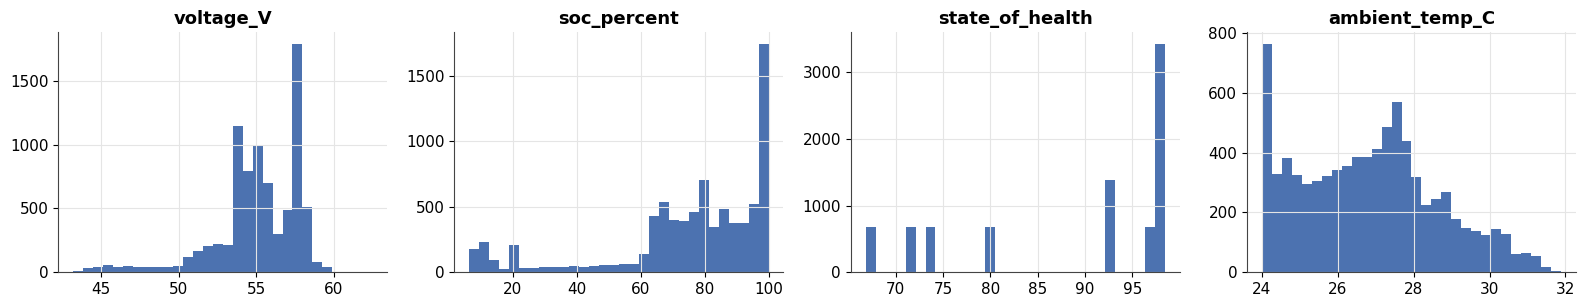

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
hist_cols = ['voltage_V', 'soc_percent', 'state_of_health', 'ambient_temp_C']
for ax, col in zip(axes, hist_cols):
    ax.hist(df[col].dropna(), bins=30, color=NORMAL_COLOR)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Voltage and SOC both show the shape you'd expect from a fleet that spends a lot of its time sitting fully (or near-fully) charged — a tall spike near the top of each range. `state_of_health` is the one worth pausing on: rather than a smooth spread, it shows **distinct spikes with gaps between them**, because each battery reports essentially one SOH value across its whole 6-hour session — this histogram is really 12 stacked spikes, not a continuous distribution. Even at this raw stage, before any per-battery summarising or modelling, those spikes already cluster into two visibly separate groups — roughly 67–80% and roughly 92–98% — foreshadowing the bimodal split the rest of this notebook investigates formally.

**How the signals relate to each other.** Restricting to `in_use` (riding) readings — the regime the rest of this notebook focuses on — makes the relationships between signals interpretable; during charging or idle several of these are simply constant (e.g. `speed_kph` is always 0), which would just add noise to a correlation.

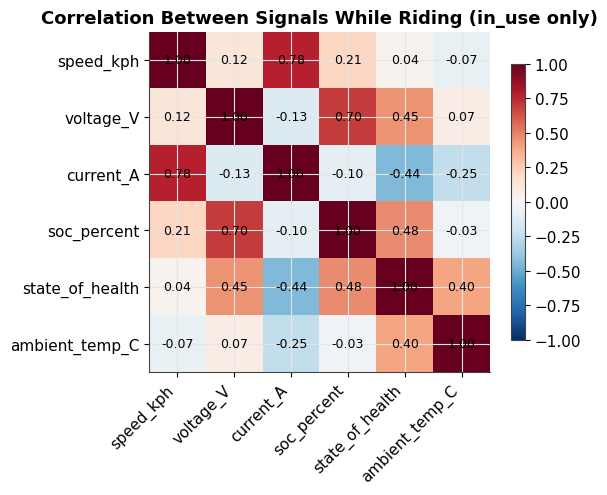

In [4]:
num_cols = ['speed_kph', 'voltage_V', 'current_A', 'soc_percent', 'state_of_health', 'ambient_temp_C']
corr = df.loc[df['state'] == 'in_use', num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=9)
ax.set_title('Correlation Between Signals While Riding (in_use only)')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

Two relationships are exactly what real telemetry should show, which is a useful data-quality sanity check in its own right: **speed and current draw move together** (0.78 — riding faster pulls more current), and **voltage tracks state of charge** (0.70 — a pack's voltage sags as it empties, standard lithium-ion behaviour). More relevant to the question this notebook is answering: **state of health is negatively correlated with current draw** (−0.44) — batteries in worse health pull more current to do the same riding. That's not proof on its own, but it's an independent line in the raw data already pointing the same direction as everything that follows.

**One more look before any modelling: the raw SOC trajectories, unlabelled.**

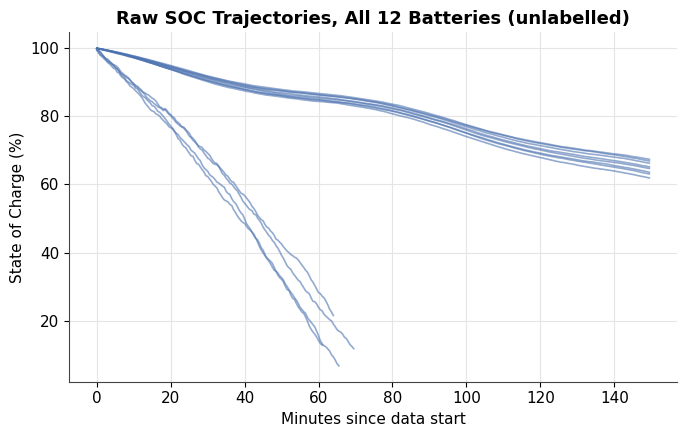

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for bid, g in df.groupby('battery_id'):
    inuse = g[g['state'] == 'in_use'].dropna(subset=['soc_percent']).sort_values('timestamp')
    t_min = (inuse['timestamp'] - df['timestamp'].min()).dt.total_seconds() / 60
    ax.plot(t_min, inuse['soc_percent'], color=NORMAL_COLOR, alpha=0.6, linewidth=1.2)
ax.set_xlabel('Minutes since data start')
ax.set_ylabel('State of Charge (%)')
ax.set_title('Raw SOC Trajectories, All 12 Batteries (unlabelled)')
plt.tight_layout()
plt.show()

No colour-coding, no thresholds, no model — just the raw data. Four lines are already visibly different from the rest: they fall steeply and stop well before the other eight, which continue on a shared, gentle decline out to the full ~150-minute session. That's the pattern this whole notebook exists to investigate properly — is that visual difference real and specific to those units, or noise? Sections 5 onward answer that with engineered features, a tested model, and statistics rather than an eyeball call. It's worth being honest, though, that the eyeball call already looks right here.